# Demo

This demo of the package is divided into 3 parts:

1. In part 1, **"Manual" demo**, we expose the calibration internals of the package by creating a toy USD curveset with SOFR & FF curves, and using it in a calibration problem. The goal of this part is to expose the internal flow of curves and curvesets in a minimal example, and solving the problem via jax. Naturally, in a production library this is all typically hidden under a curve orchestrator and calibrator, as it is indeed done in this package, but it can be interesting to show the "jax flow" of a simple example out in the open.

2. In part 2, **Calibration benchmark demo**, we run a function that encapsulates a similar curveset calibration problem, now fully using the internals of the package, and benchmarks it for different "dates" and different solvers. We showing timings for a number of metrics. There's little code in this part as it is all abstracted behind a function, but the user can modify parameters like the demo curveset to use, the number of dates, etc. We also actually display some curves.

3. Part 3, **Streaming risk demo**, shows a POC where the fast calibration and jacobian computation allow the efficient calculation of risk factors. This is displayed in a dataframe with a demo portfolio and bucketed deltas for each instrument. The dataframe is "streamed" and represents a minimal example of a monitor with risk.

# 1. "Manual" demo

We're going to define a simple, demo USD curveset, with a SOFR curve and a FF curve, built as a spread. All interpolators will be stepwise constant and some mock market swaps will be provided.

Start with defining the curveset, like mentioned, with SOFR and FF as a spread (naturally, this could be reversed):

In [32]:
# Some imports
from fixed_income_ad_playground._demo.demo_cases import build_maturities_years
from fixed_income_ad_playground.calibration.calibration import (
    CurveDef,
    CurveSetSpec,
    build_curve_graph_arrays,
    make_calib_static,
)
from fixed_income_ad_playground.curve.curve_config import CurveConfig
from fixed_income_ad_playground.enums import (
    Currency,
    CurveDefKind,
    InterpType,
    PaymentFrequency,
    QuoteType,
    SwapIndex,
)
import numpy as np
from fixed_income_ad_playground.identifiers.identifiers import CurveId
from fixed_income_ad_playground.packing.swaps import pack_swaps_pooled
from fixed_income_ad_playground.reference_data_container import ReferenceDataContainer
from fixed_income_ad_playground.shape_policy import ShapePolicy
from fixed_income_ad_playground.pricing.quote import Quote
from fixed_income_ad_playground.instruments.swap import SwapSpec
from fixed_income_ad_playground.identifiers.identifiers import InstrumentId
from fixed_income_ad_playground.instruments.instrument import PackContext
from fixed_income_ad_playground.kernels.swaps import par_swap_rates_pooled
from fixed_income_ad_playground._demo.demo_cases import make_true_forward
import jax.numpy as jnp
from fixed_income_ad_playground.calibration.calibration import CurveSetCalibrator

In [33]:
SOFR = CurveId("USD_SOFR")
SPRD = CurveId("USD_FF_SPRD")
FF = CurveId("USD_FEDFUNDS")
# We don't have reference data for this demo, so we create a dummy reference
# data provider, which maps swap indices to (forecast_curve, discount_curve) pairs.


curve_defs = [
    CurveDef(SOFR, CurveDefKind.PARAM),
    CurveDef(SPRD, CurveDefKind.PARAM),
    CurveDef(FF, CurveDefKind.LINEAR_COMB, sources=((SOFR, 1.0), (SPRD, 1.0))),
]
curve_configs = {
    SOFR: CurveConfig(SOFR, interp=InterpType.STEPWISE_CONST_FWD, lam_slope=1e-4, lam_curv=1e-6),
    SPRD: CurveConfig(SPRD, interp=InterpType.STEPWISE_CONST_FWD, lam_slope=1e-4, lam_curv=1e-6),
}

spec = CurveSetSpec(curve_defs=curve_defs, curve_configs=curve_configs)

Once we have the curveset definition, we need to get the reference and market data. We don't have one so we're going to create a simple toy 25 swaps sets per curve with a max maturity of 10 years (they're equispaced in maturities, which obviously isn't realistic, but we don't care about realism at this point).

In [34]:
# For this demo, we create a dummy reference data provider, which maps swap indices to (forecast_curve, discount_curve) pairs.
refdata = ReferenceDataContainer({
    SwapIndex.USD_SOFR_OIS: (SOFR, SOFR),
    SwapIndex.USD_FF: (SOFR, FF),
})


max_t = 10.0  # max maturity in years
n_swaps = 25  # number of swaps per curve

# assume linspaced maturities for demo purposes
knot_times = np.linspace(0.0, max_t, n_swaps + 1).astype(np.float64)
# knot_times[0] = 0.0
maturities = build_maturities_years(n_swaps, max_t)

# We will also add some 'market quotes' and swaps to the demo curves
# At this point the actual quotes don't matter, we just need to build the
# Instruments and the correct Jax arrays' shapes
quotes: list[Quote] = []

# fmt: off
for m in maturities:
    quotes.extend([
        Quote(
            SwapSpec(
                InstrumentId(f"SOFR_{m:.3f}"), Currency.USD, SwapIndex.USD_SOFR_OIS, float(m),float_leg_freq=PaymentFrequency.S,
            ), QuoteType.PAR_RATE, 0.0,
        ),
        Quote(
            SwapSpec(
                InstrumentId(f"FF_{m:.3f}"), Currency.USD, SwapIndex.USD_FF, float(m), float_leg_freq=PaymentFrequency.S,
            ), QuoteType.PAR_RATE, 0.0,
        ),
    ])
# fmt: on

# This is how we pack swaps in pooled mode (vectorized across curves)
curve_id_to_idx, graph = build_curve_graph_arrays(spec.curve_defs)
batch = pack_swaps_pooled(quotes, PackContext(), refdata, curve_id_to_idx, ShapePolicy())

# Build calibration static data
static = make_calib_static(knot_times, graph, batch, spec)

Now we can build the true curve. This is what we intend to match:

In [35]:
P = len(static.param_curve_ids)
N = int(knot_times.size - 1)
x0 = np.zeros((P * N,), dtype=np.float64) + 0.02

forward_blocks = []
for k in range(P):
    forward_blocks.append(
        make_true_forward(knot_times, level=0.03 + 0.002 * k, slope=0.01, wiggle=0.001)
    )

# params_true is the concatenation of all true forward curves' parameters
true_forwards = np.concatenate(forward_blocks, axis=0).astype(np.float64)

market_par_rates = par_swap_rates_pooled(
    jnp.array(true_forwards), static.knot_times, static.graph, static.batch
)

Instantiate our calibrator and get the jitted solver

In [36]:
calib = CurveSetCalibrator(static)

# run_jit is the optimization function
solver_jit, (solver_obj, fn) = calib.build_optx_least_squares_value_only(
    solver_kind="gn", max_steps=20, jac_mode="fwd"
)

We will then run the solver. You can check that the first time it may take a few tenths due to jit warmup, but subsequent times will be near-instant. This is useful as we can persist a calibrator across different dates, and exploit the jitted performance.

In [37]:
calibrated_forwards = solver_jit(jnp.array(x0), market_par_rates)
calibrated_forwards.block_until_ready()

Array([0.03206139, 0.03519639, 0.03727232, 0.03851629, 0.03911752,
       0.03926009, 0.03913193, 0.03891434, 0.03876144, 0.03877825,
       0.03900575, 0.03941778, 0.03993269, 0.04043665, 0.04081412,
       0.04097771, 0.04089123, 0.04057863, 0.04011867, 0.03962547,
       0.03922214, 0.03901496, 0.0390672 , 0.03934841, 0.03966612,
       0.03406394, 0.03719318, 0.03927193, 0.04051562, 0.04111647,
       0.04125886, 0.0411312 , 0.04091483, 0.04076367, 0.04078221,
       0.04101078, 0.04142235, 0.04193493, 0.04243494, 0.04280766,
       0.04296695, 0.04287835, 0.04256735, 0.04211397, 0.04163314,
       0.04124646, 0.04105184, 0.04109375, 0.04132443, 0.0415732 ],      dtype=float64)

That's it! Those are the calibrated forward (knot) values for the different curves. Naturally, they're calculated in an array that then should be masked to the different curves, but the calibration problem is done.

# 2. Calibration benchmark demo

Here, we have prepared a function that runs a benchmark for a demo USD curveset, with different solvers, dates, etc.

What this does, by default, is generate synthetic market quotes across 20 dates, and calibrate curves for those twenty dates with a few different solvers.
It will then print some timing statistics. 

For our use case, the Gauss-Newton solver from the `optimistix` library (jax-compatible; think scipy optimisers but with jax arrays instead of numpy) is the best performant. It typically calibrates the curveset in 3-4ms with a fit RMS ~0.001-0.002bp. We also use other solvers, including solvers that don't use the explicitly calculated jacobian.

We also plot the zero and the instantaneous forward rates (ifr) curves calibrated for one of the dates, as an example. Note that, for demo purposes, we use stepwise-constant ifr curves, but the problem would be exactly the same with another interpolator type.


=== Demo: USD-2curve-50swaps ===
case=usd_50  n_dates=20  warm_start=True
solver max_steps=100  jac_mode=fwd
true shapes: swaps=54 max_cf=40 pooled_Q=62
bucketed shape key: S=64 M=64 Q=64 | curves=3 param_curves=2 N=27 maxT=10.0
market generation: 0.000s (kernel warmup=0.260s)
residual+jac warmup: 1.638s

--- Benchmark (compile excluded from steady-state; per-date solve times) ---
Optimistix LS-GN (uses J)           | compile=  1.077s | median=    4.564ms | p90=    5.401ms | max=    6.190ms | fit(last): RMS=0.0015bp max=0.0108bp
    stats(first): steps=5 result=0 | stats(last): steps=2 result=0
Optimistix LS-DOGLEG (uses J)       | compile=  1.621s | median=    5.955ms | p90=    7.010ms | max=    7.588ms | fit(last): RMS=0.0015bp max=0.0108bp
    stats(first): steps=5 result=0 | stats(last): steps=3 result=0
Optimistix LS-LM (uses J)           | compile=  1.549s | median=  106.044ms | p90=  122.851ms | max=  126.883ms | fit(last): RMS=0.0015bp max=0.0108bp
    stats(first): steps=29 r

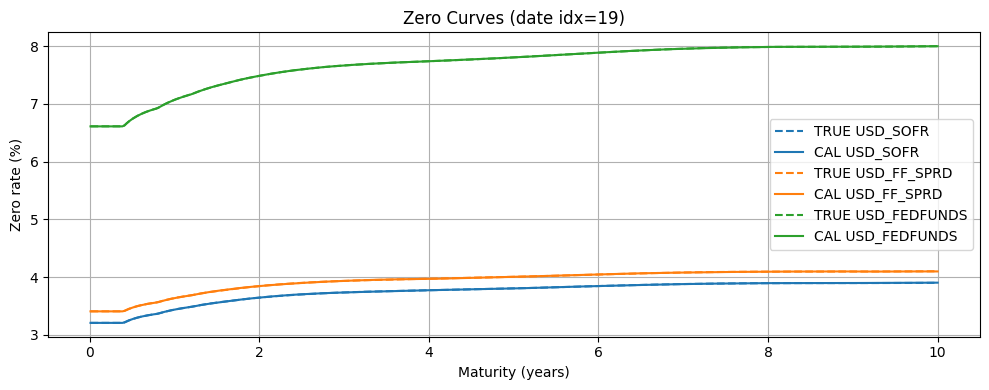

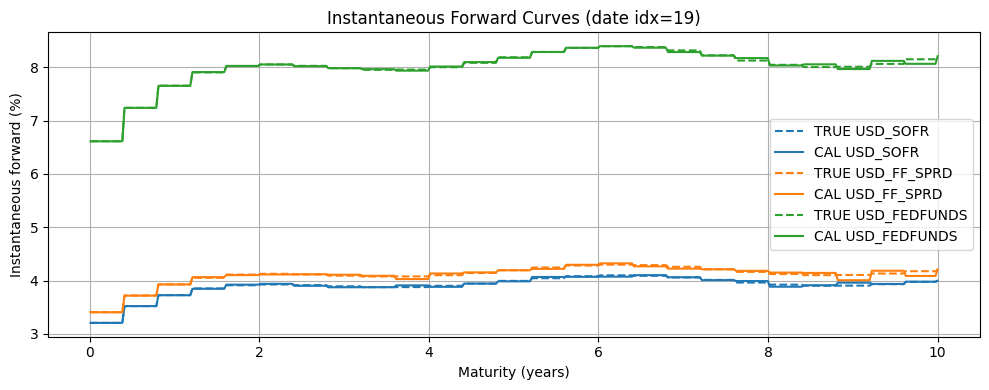

In [38]:
from fixed_income_ad_playground._demo.main import main_benchmark


main_benchmark(
    n_dates=20,  # number of "dates" to benchmark (i.e. number of times to run the calibration, simulating a time series)
    warm_start=True,
    noise_bps=0.1,  # noise level in bps to add to the synthetic market quotes (only for swaps in this demo case)
    max_steps=100,  # maximum number of optimization steps for the calibrator. In reality, 80 steps is overkill and should converge earlier.
    # jacobian mode for the optimistix least squares solver. Can be "fwd" or "bwd". In general, "fwd" is faster but depends on the calibration problem
    jac_mode="fwd",
    plot=True,
    plot_date_idx=None,
)

# 3. Streaming risk demo

This is perhaps the most interesting demo.

The following function will calibrate a similar USD curveset with "live tick data" and use it to price a portfolio of spot and forward swaps, as well as bucketed deltas.

This is done in a streaming fashion representing a live monitor. By default it's set to update every 0.5s, but it could be done a lot faster (not that it would be very readable). 

As before, there's a bit of a cold start to it as it jit-compiles all the required functions, but after that, they can be reused across different ticks/dates to calibrate new curves very efficiently, which is why it allows the fast streaming of data.

In [40]:
from fixed_income_ad_playground._demo.demo_risk_df import main_risk

main_risk(
    iterations=100,  # number of ticks to demo
    noise_bps=0.2,  # noise level in bps to add to the synthetic market quotes
    jac_mode="fwd",
    sleep_seconds=0.5,  # seconds to sleep between ticks, to simulate time passing and let the user see the printed output
)

,instrument_id,Par,DV01_0.0-1.0Y,DV01_1.0-3.0Y,DV01_3.0-5.0Y,DV01_5.0-10.0Y,DV01_10.0-30.0Y,tick index
0,USD_SOFR_OIS_3M,0.035749,25.005600,0.000000,0.000000,0.000000,0.0,99
1,USD_SOFR_OIS_6M,0.035908,50.008190,0.000000,0.000000,0.000000,0.0,99
2,USD_SOFR_OIS_9M,0.039245,74.363027,0.000000,0.000000,0.000000,0.0,99
3,USD_SOFR_OIS_1Y,0.041024,98.553549,0.000000,0.000000,0.000000,0.0,99
4,USD_SOFR_OIS_2Y,0.024397,101.015906,97.737003,0.000000,0.000000,0.0,99
5,USD_SOFR_OIS_3Y,0.033779,99.313080,188.763557,0.000000,0.000000,0.0,99
6,USD_SOFR_OIS_5Y,0.033778,99.942984,189.677866,176.487451,0.000000,0.0,99
7,USD_SOFR_OIS_7Y,0.016865,112.075993,213.558327,199.869716,186.585749,0.0,99
8,USD_SOFR_OIS_10Y,0.038676,99.041555,186.974916,172.621447,371.946758,0.0,99
9,USD_SOFR_OIS_Fwd1Yx1Y,0.007449,-0.711740,95.304211,0.000000,0.000000,0.0,99
